<font size="6">Demo of Overlapping Areas</font>

First we import some packages

In [1]:
import numpy as np
import pyPolygon as pp
from matplotlib import pyplot as plt

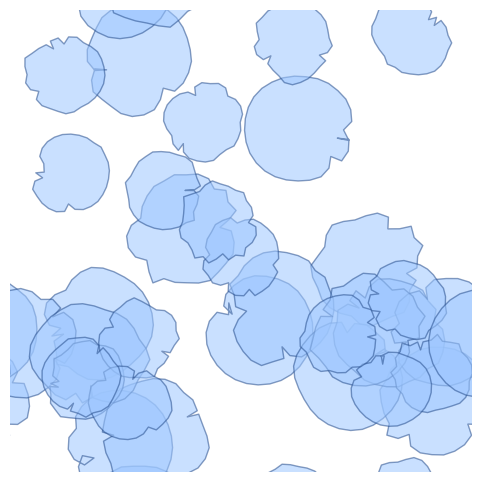

In [2]:
packing = pp.Model(N = 32, n = 32, seed = 42)
# The default if a seed isn't specified is to generate a random seed
packing.generateEquilateralPolygons(phi = 1.0, kappa = 4.0)
packing.setBiPerimeter() # first half small. second half large. default ratio 1.4
# Periodic boundary conditions are set by default, but you may try "free" boundary 
# conditions if you want to experiment:
packing.setBoundaryConditions("periodic") # The default is "periodic" so you don't need this line
packing.draw()
plt.show()

Next we need to set the spring constants for the various energy terms.
Let's start out with no adhesion. The default is for the area and edge springs to have a spring constant of 1 and the overlap spring is always 1 as it sets the overall scale for the default model type ("sharp").

packing.setSpringConstants(adhesion = 0, area = 1, perimeter = 0, edge = 1)

In [3]:
packing.setSpringConstants()

Now we can draw the forces

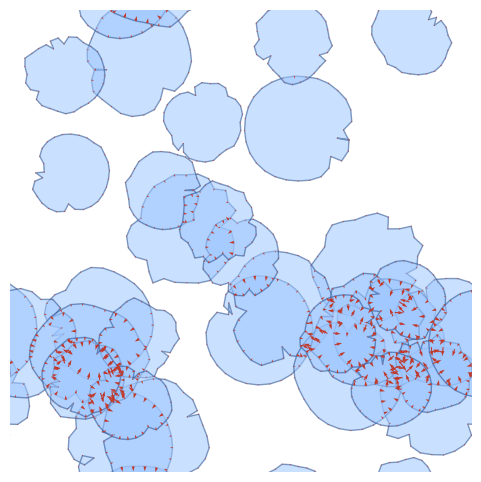

In [4]:
packing.initForceEnergy()
packing.calcForceEnergy()
packing.draw(forces = packing.getForces())
plt.show()

Another option is to constrain the areas and perimeters and edges. Let's proceed with that instead. We call setConstraints. Calling this will ignore the springs on these variables as any forces would get projected out anyway.

These are the defaults:
packing.setConstraints(area = True, perimeter = False, edge = True)

In [5]:
packing.setConstraints()

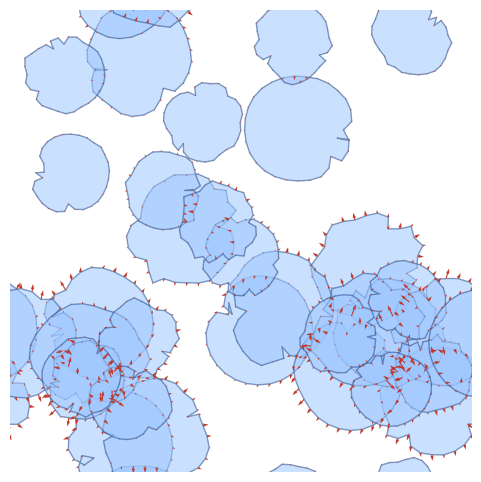

In [6]:
packing.initForceEnergy()
packing.calcForceEnergy()
packing.draw(forces = packing.getForces())
plt.show()

# Mollification

In [7]:
packing.setModelType("mollified")
packing.setMollification(sigma = 1e-2)

We should visualize the indicators to see how extreme the mollification width is

<Axes: >

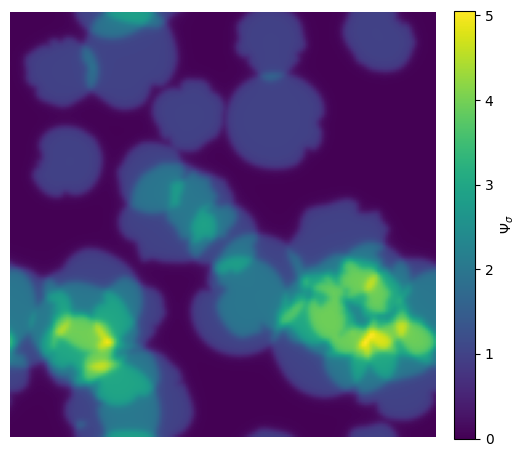

In [8]:
packing.draw(indicatorColorMap = 'viridis')

Now we can proceed with finding the forces and drawing them as arrows

<Axes: >

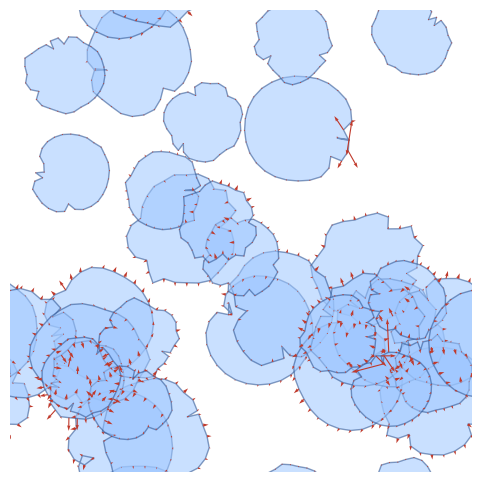

In [9]:
packing.initForceEnergy()
packing.calcForceEnergy()
forces = packing.getForces()
packing.draw(forces = forces)

Now we can try minimizing this with FIRE. Let's start with 10,000 steps and show a progress bar

FIRE (constrained):   0%|          | 0/10000 [00:00<?, ?it/s]

This was after 613 steps.


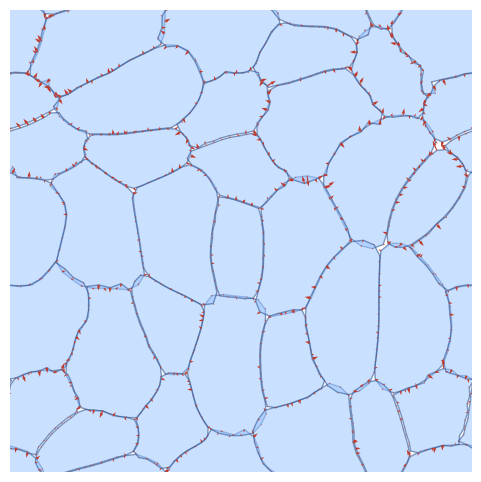

In [10]:
steps = packing.minimizeFIRE(maxSteps = 10_000, fThreshold = 1e-3, progressBar = True)
packing.draw(forces = packing.getForces())
print("This was after " + str(steps) + " steps.")

From here we can minimize with CG to polish

In [ ]:
packing.minimizeCG(maxSteps = 1_000, fThreshold = 1e-9)
packing.draw(forces = packing.getForces())
print("The maximum unbalanced force is " + str(packing.getMaxUnbalancedForce()))

CG (constrained):   0%|          | 0/1000 [00:00<?, ?it/s]